<a href="https://colab.research.google.com/github/Atharva-3954/ML-Project-Pluto/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

For this project I used the Titanic dataset which contains information about passengers such as age, gender, ticket class and fare.

I wanted to predict whether a passenger survived or not using machine learning models. I also compared different models to see which one gives better results.

This project helped me practice data preprocessing, model training and evaluation using Python and scikit-learn.

## Problem Statement
The goal is to predict whether a passenger survived the Titanic disaster based on features like age, gender, ticket class, fare, and family size.

**Dataset Used:**
- `train.csv` – used to train the models
- `test.csv` – used to generate final predictions
- `gender_submission.csv` – used only for format reference


## 1. Import Libraries

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [31]:
import pandas as pd

# Load datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
gender_df = pd.read_csv('gender_submission.csv')

# Create a raw copy for EDA plots that need original categorical values
train_df_raw = train_df.copy()

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)


Train shape: (891, 12)
Test shape: (418, 11)


## 3. Dataset Overview

In [32]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [33]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [34]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [35]:
# check missing values
print('Missing values in train data:')
print(train_df.isnull().sum())

Missing values in train data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Observations:**
- `Age` has around 177 missing values — that's a lot, so I filled it with median.
- `Cabin` has 687 missing values out of 891, so I just dropped it.
- `Embarked` only has 2 missing values, easy to fix with mode.


## 4. Data Cleaning

In [36]:
# Fill missing Age with median
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
test_df['Age'].fillna(test_df['Age'].median(), inplace=True)

# Fill missing Embarked with mode
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)

# Fill missing Fare in test (only 1 missing value)
test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)

# Drop columns that are not useful
cols_to_drop = ['Name', 'Ticket', 'Cabin', 'PassengerId']
train_df.drop(columns=cols_to_drop, inplace=True)
test_df.drop(columns=['Name', 'Ticket', 'Cabin'], inplace=True)

print('Missing values after cleaning:')
print(train_df.isnull().sum())

Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [37]:
# Encode categorical columns
le = LabelEncoder()

train_df['Sex'] = le.fit_transform(train_df['Sex'])          # male=1, female=0
train_df['Embarked'] = le.fit_transform(train_df['Embarked'])

test_df['Sex'] = le.fit_transform(test_df['Sex'])
test_df['Embarked'] = le.fit_transform(test_df['Embarked'])

train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


## 5. Exploratory Data Analysis

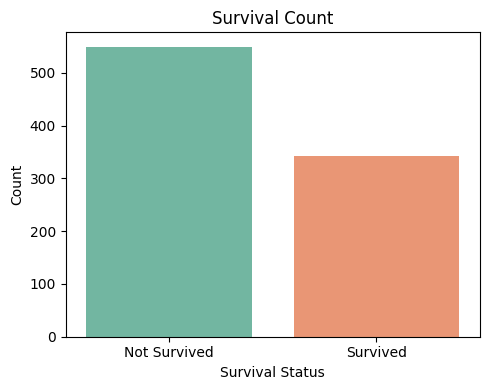

In [38]:
# Survival Count
plt.figure(figsize=(5, 4))
sns.countplot(x='Survived', data=train_df, palette='Set2')
plt.title('Survival Count')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.xlabel('Survival Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

More passengers didn't survive than survived. The dataset is slightly imbalanced.

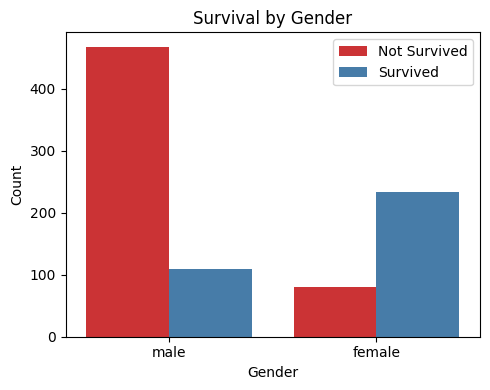

In [39]:
# Survival by Gender
plt.figure(figsize=(5, 4))
sns.countplot(x='Sex', hue='Survived', data=train_df_raw, palette='Set1')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Not Survived', 'Survived'])
plt.tight_layout()
plt.show()

Females survived at a much higher rate than males. Gender looks like a strong predictor.

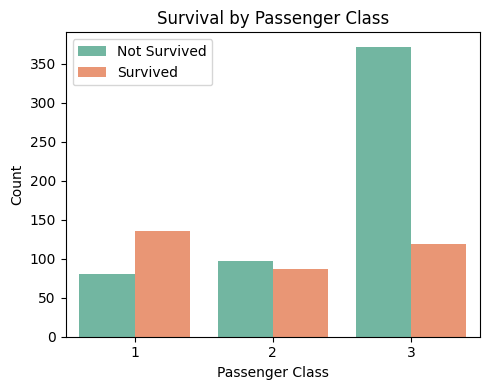

In [40]:
# Survival by Passenger Class
plt.figure(figsize=(5, 4))
sns.countplot(x='Pclass', hue='Survived', data=train_df_raw, palette='Set2')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(['Not Survived', 'Survived'])
plt.tight_layout()
plt.show()

First-class passengers had much better survival rates. Third class had the most deaths overall.

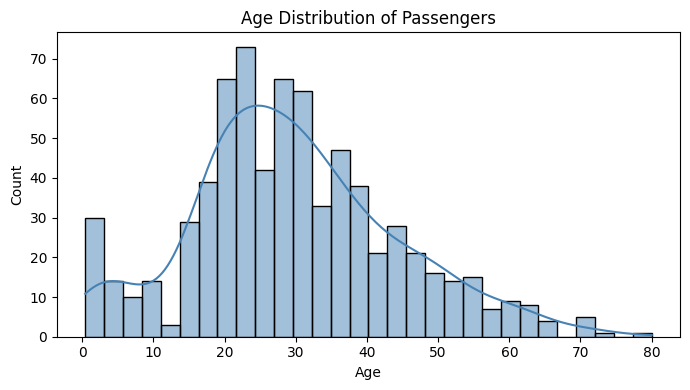

In [41]:
# Age Distribution
plt.figure(figsize=(7, 4))
sns.histplot(train_df_raw['Age'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most passengers were between 20–40 years old. There are also some children in the data.

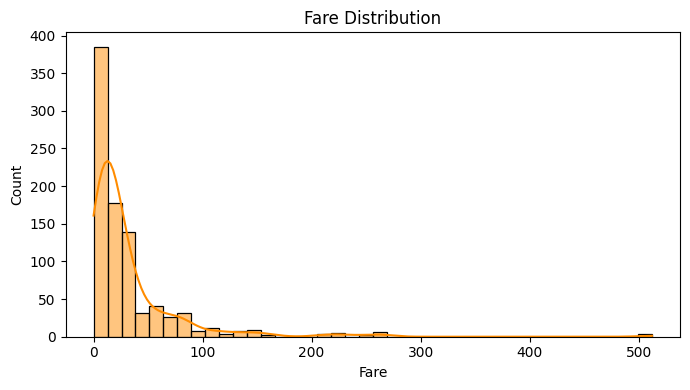

In [42]:
# Fare Distribution
plt.figure(figsize=(7, 4))
sns.histplot(train_df_raw['Fare'], bins=40, kde=True, color='darkorange')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most people paid low fares. A few outliers paid very high amounts — probably first class passengers.

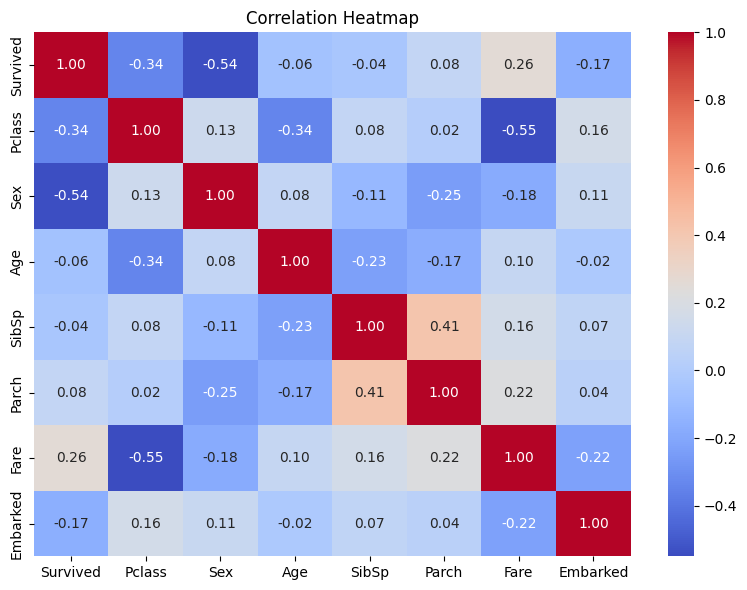

In [43]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(train_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Sex and Pclass have the strongest correlation with survival. Fare also has a moderate positive correlation.

## 6. Feature Engineering

Here I separated features from the target and checked which features matter most before splitting the data.


In [44]:
# Separating features and target
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

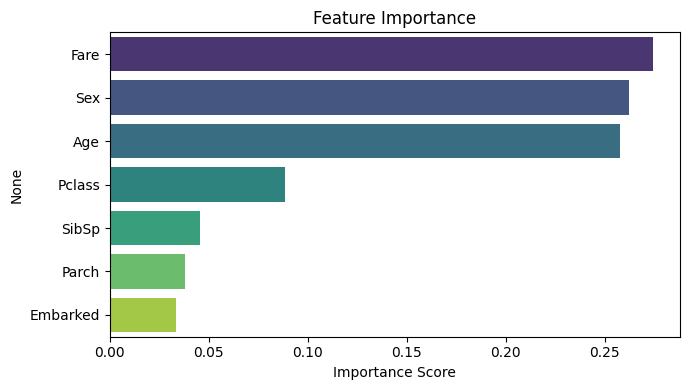

Fare        0.274307
Sex         0.262157
Age         0.257884
Pclass      0.088450
SibSp       0.045523
Parch       0.038107
Embarked    0.033572
dtype: float64


In [45]:
# check feature importance using Random Forest
rf_check = RandomForestClassifier(n_estimators=100, random_state=42)
rf_check.fit(X, y)

feat_imp = pd.Series(rf_check.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feat_imp)

Sex, Fare, and Age came out as the most important features. I kept all features since they all contribute.

**Feature Importance Summary:**
- `Sex`, `Fare`, and `Age` are the top predictors — gender and ticket price seem to matter the most.
- `Embarked`, `Parch`, and `SibSp` have lower importance but are still kept.
- Columns like `Name`, `Ticket`, and `Cabin` were dropped — too many missing values or not useful for prediction.


In [46]:
# Train-test split (80-20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training size:', X_train.shape)
print('Validation size:', X_val.shape)

Training size: (712, 7)
Validation size: (179, 7)


Split the data 80/20 for training and validation. The validation set is used to check model performance on unseen data.

## 7. Model Building

In [47]:
# Model 1 - Logistic Regression
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_val)
lr_acc = accuracy_score(y_val, lr_pred)
print('Logistic Regression Accuracy:', round(lr_acc, 4))

Logistic Regression Accuracy: 0.8101


In [48]:
# Model 2 - Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_val)
dt_acc = accuracy_score(y_val, dt_pred)
print('Decision Tree Accuracy:', round(dt_acc, 4))

Decision Tree Accuracy: 0.7821


In [49]:
# Model 3 - Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)
rf_acc = accuracy_score(y_val, rf_pred)
print('Random Forest Accuracy:', round(rf_acc, 4))

Random Forest Accuracy: 0.8212


## 8. Model Evaluation

In [50]:
# model accuracy comparison
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [round(lr_acc, 4), round(dt_acc, 4), round(rf_acc, 4)]
})
comparison = comparison.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('Model Accuracy Comparison:')
comparison

Model Accuracy Comparison:


,Model,Accuracy
0,Random Forest,0.8212
1,Logistic Regression,0.8101
2,Decision Tree,0.7821


**From the comparison table:**
- Random Forest performed the best among all three models.
- Logistic Regression was close behind.
- Decision Tree had the lowest score — probably overfitting on training data.


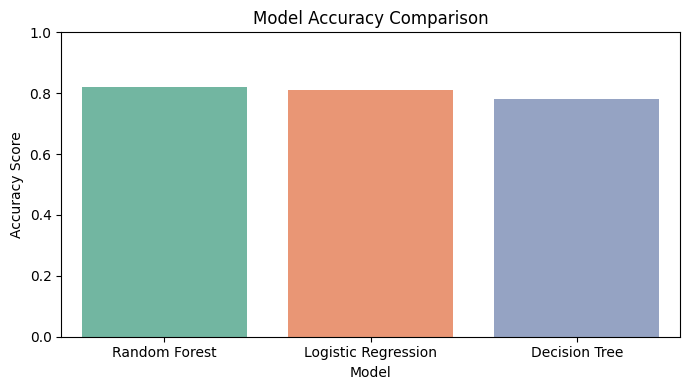

In [51]:
# Bar chart for accuracy comparison
plt.figure(figsize=(7, 4))
sns.barplot(x='Model', y='Accuracy', data=comparison, palette='Set2')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.ylabel('Accuracy Score')
plt.tight_layout()
plt.show()

**Best Model — Random Forest:**
- Handled feature interactions better than a single decision tree.
- Less prone to overfitting compared to Decision Tree.
- Downside: slower to train and harder to interpret.


In [52]:
# Finding best model
best_model_name = comparison.iloc[0]['Model']
print('Best Model:', best_model_name)

best_pred_map = {
    'Logistic Regression': lr_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred
}
best_pred = best_pred_map[best_model_name]

Best Model: Random Forest


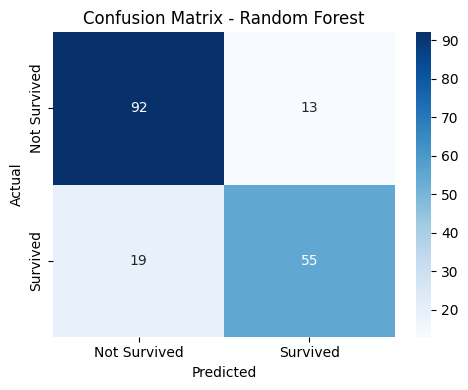

In [53]:
# Confusion Matrix for best model
cm = confusion_matrix(y_val, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

**From the confusion matrix:**
- 92 passengers correctly predicted as not survived (True Negatives)
- 55 correctly predicted as survived (True Positives)
- 13 predicted survived but actually didn't (False Positives)
- 19 predicted not survived but actually did (False Negatives)


In [54]:
# Classification Report for best model
print(f'Classification Report - {best_model_name}:')
print(classification_report(y_val, best_pred, target_names=['Not Survived', 'Survived']))

Classification Report - Random Forest:
              precision    recall  f1-score   support

Not Survived       0.83      0.88      0.85       105
    Survived       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



## 9. Prediction on Test Dataset

In [55]:
test_passenger_ids = test_df['PassengerId']
test_df.drop(columns=['PassengerId'], inplace=True)

In [56]:
# Train best model on full training data before predicting
best_model_map = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

final_model = best_model_map[best_model_name]
final_model.fit(X, y)

# Predict on test data
test_predictions = final_model.predict(test_df)
print('Predictions done. Sample predictions:', test_predictions[:10])

Predictions done. Sample predictions: [0 0 0 1 0 0 0 0 1 0]


**Note:** `test.csv` doesn't have actual `Survived` labels, so we can't directly evaluate accuracy on it. The `gender_submission.csv` is just for submission format. Model performance should be judged from the validation split above.


In [57]:
# Final submission file
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': test_predictions
})
submission.to_csv('submission.csv', index=False)
print('Submission file saved as submission.csv')
submission.head(10)

Submission file saved as submission.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0


## 10. Conclusion

- Cleaned the Titanic dataset by filling missing values and encoding categorical columns.
- Trained three models — Logistic Regression, Decision Tree, and Random Forest.
- Random Forest gave the best accuracy on the validation set.
- Gender and passenger class were the most important factors for survival prediction.
- This project helped me understand the full ML pipeline from data cleaning to model evaluation.


## 11. Future Improvements

- Try hyperparameter tuning using GridSearchCV.
- Use k-fold cross-validation for more reliable accuracy estimates.
- Create new features like `FamilySize` or extract `Title` from passenger names.
- Test other algorithms like Gradient Boosting or SVM.


In [58]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


**Summary:**
- Data was cleaned and preprocessed for model training.
- Random Forest performed best out of the three models.
- Gender and class had the biggest impact on survival.
- Overall this project gave me hands-on experience with a real ML classification problem.
